In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import re
import pandas as pd
import torch

from vis import (
    Plotter,
    _window_and_filter,
    load_embeddings_pt,
    centroids_by_token,
)

from utils import (
    load_graph_from_txt, 
    dirichlet_energy_laplacian, 
    compute_rule_following_accuracy_over_records, 
    parse_tree_text,
    tree_to_graph,
    build_word_centroid_map,
    aggregate_cluster_centroids,
    )

# Paper Grid

Grid - #nodi: 16 #archi: 24


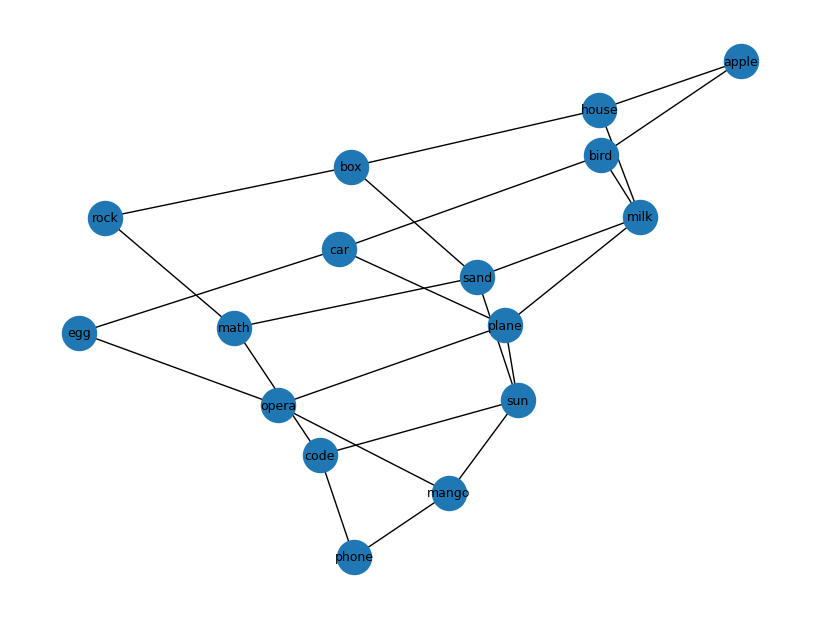

In [2]:
VOCAB_PATH = Path("../data/paper-tkid-map.txt")
grid_folder = "paper_grid"
structure_name = "paper_grid"

EMB_DIR    = Path(f"../embeddings/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # layout automatico
nx.draw(
    G, pos,
    with_labels=True,
    node_size=600,
    font_size=9
)
plt.show()

In [3]:
from sklearn.decomposition import PCA

ctx = 3000
WIN = 300
PCA_K = 10
MIN_NODES = PCA_K + 1

all_results = []

pt_path = EMB_DIR / f"reprs_{structure_name}_one_rw_{ctx}_line000000_layer31.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)
t_end_ref = min(ctx, T_file)

CONTEXT_LENS = list(range(WIN, t_end_ref + 1, WIN))
if CONTEXT_LENS[-1] != t_end_ref:
    CONTEXT_LENS.append(t_end_ref)

graph_nodes = list(G.nodes())

print(f"\n=== CTX={ctx} | file_len={T_file} | t_end_ref={t_end_ref} ===")

for win_len in CONTEXT_LENS:
    t0 = max(0, t_end_ref - win_len)
    t1 = t_end_ref

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np, emb_np, hp_grid.id_to_word,
        k=50,
        t_start=t0, t_end=t1,
        title=f"ctx={ctx}, win_len={win_len}, local=[{t0}:{t1})"
    )

    if len(filtered_ids) == 0:
        all_results.append({
            "ctx": ctx, "context_len": win_len,
            "t_start_local": t0, "t_end_local": t1,
            "energy": np.nan, "energy_per_edge": np.nan,
            "n_filtered": 0, "n_centroids": 0,
            "n_common": 0, "n_edges_subgraph": 0,
        })
        continue

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    if len(centroid_ids) == 0:
        all_results.append({
            "ctx": ctx, "context_len": win_len,
            "t_start_local": t0, "t_end_local": t1,
            "energy": np.nan, "energy_per_edge": np.nan,
            "n_filtered": len(filtered_ids), "n_centroids": 0,
            "n_common": 0, "n_edges_subgraph": 0,
        })
        continue

    labels = [hp_grid.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]
    idx = {lab: i for i, lab in enumerate(labels)}
    common = [node for node in graph_nodes if node in idx]

    if len(common) < MIN_NODES:
        E = E_per_edge = np.nan
        m = 0
    else:
        X_common = np.stack([centroids[idx[lab]] for lab in common], axis=0).astype(np.float64)
        X_common = X_common - X_common.mean(axis=0, keepdims=True)

        k = min(PCA_K, len(common) - 1)
        pca = PCA(n_components=k)
        X_pca = pca.fit_transform(X_common)

        G_sub = G.subgraph(common).copy()
        m = G_sub.number_of_edges()

        if m == 0:
            E = E_per_edge = np.nan
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_pca)
            E_per_edge = E / m

    print(f"  CTX={ctx} | win_len={win_len} | local=[{t0}:{t1}) | E={E}")

    all_results.append({
        "ctx": ctx, "context_len": win_len,
        "t_start_local": t0, "t_end_local": t1,
        "energy": E, "energy_per_edge": E_per_edge,
        "n_filtered": len(filtered_ids), "n_centroids": len(centroid_ids),
        "n_common": len(common), "n_edges_subgraph": m,
    })


=== CTX=3000 | file_len=3001 | t_end_ref=3000 ===
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'bird' has only 5 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'mango' has only 26 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'code' has only 29 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'milk' has only 18 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'phone' has only 23 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'plane' has only 31 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'egg' has only 15 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'car' has only 14 occurrences in [2700:30

In [4]:

# # === Carica file ===
# logit_file = EMB_DIR / f"logit_lens_every100tok_{structure_name}_one_rw_3000_layer31.pt"

# # Carica
# data = torch.load(logit_file, map_location="cpu")

# records = data.get("records", [])

# for rec in records:
#     pos1 = rec.get("token_position_1based")
#     observed = rec.get("input_token_str", rec.get("last_input_token_str", ""))

#     print(f"\nToken #{pos1} | osservato: {repr(observed)}")
#     print("-" * 60)

#     # Se hai top_decoded usa quello (più leggibile), altrimenti fallback su top_tokens
#     pred_strings = rec.get("top_decoded") or rec.get("top_tokens", [])
#     pred_probs = rec.get("top_probs", [])

#     for s, p in zip(pred_strings, pred_probs):
#         print(f"{repr(s):<20}  {p:.6f}")

In [5]:
logit_file = EMB_DIR / f"logit_lens_every100tok_{structure_name}_one_rw_3000_layer31.pt"

# Carica
data = torch.load(logit_file, map_location="cpu")

records = data.get("records", [])

summary, df_rule = compute_rule_following_accuracy_over_records(records, G, lowercase=True)

# df_rule[[
#     "token_position_1based",
#     "observed_raw",
#     "rule_following_mass_topk",
#     "num_matched_preds",
#     "matched_preds"
# ]]

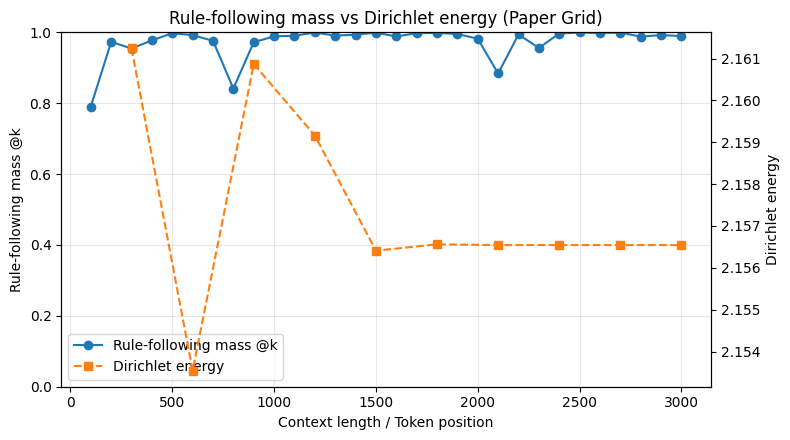

In [6]:
df = pd.DataFrame(all_results)
df_plot = df.dropna(subset=["energy"]).copy().sort_values("context_len")

fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(
    df_rule["token_position_1based"],
    df_rule["rule_following_mass_topk"],
    marker="o", label="Rule-following mass @k"
)
ax1.set_xlabel("Context length / Token position")
ax1.set_ylabel("Rule-following mass @k")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["context_len"], df_plot["energy"],
    marker="s", linestyle="--", color="tab:orange", label="Dirichlet energy"
)
ax2.set_ylabel("Dirichlet energy")

plt.title("Rule-following mass vs Dirichlet energy (Paper Grid)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.tight_layout()
plt.show()

# OUR Grid

In [7]:
VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")
grid_folder = "grid_16"
structure_name = "grid_dataset"

EMB_DIR    = Path(f"../embeddings/{grid_folder}/")
GRID_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

hp_grid = Plotter(VOCAB_PATH, GRID_PATH, EMB_DIR)


Grid - #nodi: 16 #archi: 24


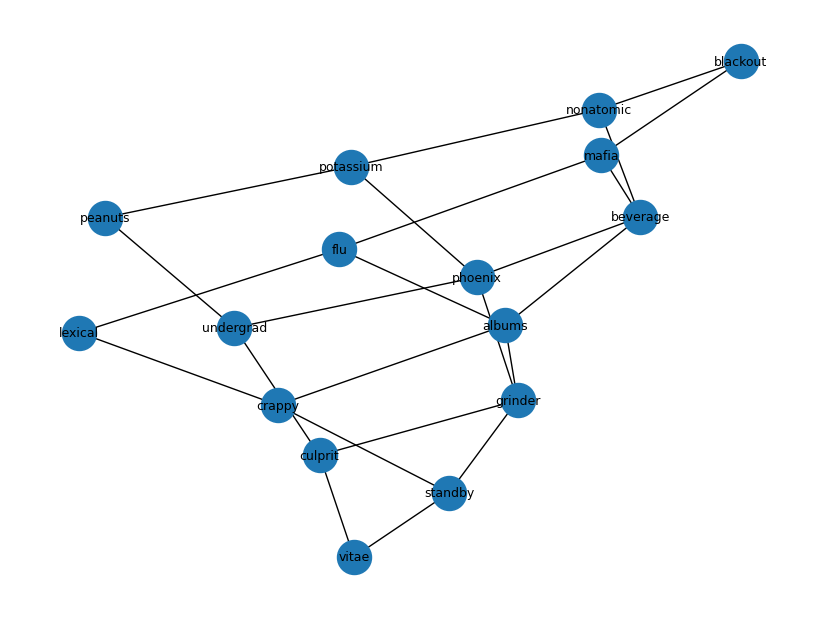

In [8]:

G = load_graph_from_txt(GRID_PATH, kind="grid")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)  # layout automatico
nx.draw(
    G, pos,
    with_labels=True,
    node_size=600,
    font_size=9
)
plt.show()


=== CTX=3000 | file_len=3002 | t_end_ref=3000 ===
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'blackout' has only 1 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'peanuts' has only 11 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'potassium' has only 16 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'vitae' has only 23 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'nonatomic' has only 8 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'standby' has only 26 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'mafia' has only 5 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'flu' has only 14 occur

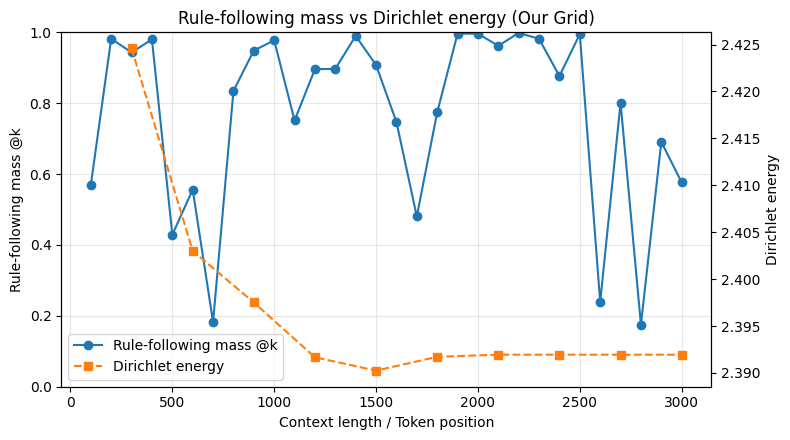

In [9]:


ctx = 3000
WIN = 300
PCA_K = 10
MIN_NODES = PCA_K + 1

all_results = []

pt_path = EMB_DIR / f"reprs_{structure_name}_one_rw_{ctx}_line000000_layer31.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)
t_end_ref = min(ctx, T_file)

CONTEXT_LENS = list(range(WIN, t_end_ref + 1, WIN))
if CONTEXT_LENS[-1] != t_end_ref:
    CONTEXT_LENS.append(t_end_ref)

graph_nodes = list(G.nodes())

print(f"\n=== CTX={ctx} | file_len={T_file} | t_end_ref={t_end_ref} ===")

for win_len in CONTEXT_LENS:
    t0 = max(0, t_end_ref - win_len)
    t1 = t_end_ref

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np, emb_np, hp_grid.id_to_word,
        k=50,
        t_start=t0, t_end=t1,
        title=f"ctx={ctx}, win_len={win_len}, local=[{t0}:{t1})"
    )

    if len(filtered_ids) == 0:
        all_results.append({
            "ctx": ctx, "context_len": win_len,
            "t_start_local": t0, "t_end_local": t1,
            "energy": np.nan, "energy_per_edge": np.nan,
            "n_filtered": 0, "n_centroids": 0,
            "n_common": 0, "n_edges_subgraph": 0,
        })
        continue

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    if len(centroid_ids) == 0:
        all_results.append({
            "ctx": ctx, "context_len": win_len,
            "t_start_local": t0, "t_end_local": t1,
            "energy": np.nan, "energy_per_edge": np.nan,
            "n_filtered": len(filtered_ids), "n_centroids": 0,
            "n_common": 0, "n_edges_subgraph": 0,
        })
        continue

    labels = [hp_grid.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]
    idx = {lab: i for i, lab in enumerate(labels)}
    common = [node for node in graph_nodes if node in idx]

    if len(common) < MIN_NODES:
        E = E_per_edge = np.nan
        m = 0
    else:
        X_common = np.stack([centroids[idx[lab]] for lab in common], axis=0).astype(np.float64)
        X_common = X_common - X_common.mean(axis=0, keepdims=True)

        k = min(PCA_K, len(common) - 1)
        pca = PCA(n_components=k)
        X_pca = pca.fit_transform(X_common)

        G_sub = G.subgraph(common).copy()
        m = G_sub.number_of_edges()

        if m == 0:
            E = E_per_edge = np.nan
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_pca)
            E_per_edge = E / m

    print(f"  CTX={ctx} | win_len={win_len} | local=[{t0}:{t1}) | E={E}")

    all_results.append({
        "ctx": ctx, "context_len": win_len,
        "t_start_local": t0, "t_end_local": t1,
        "energy": E, "energy_per_edge": E_per_edge,
        "n_filtered": len(filtered_ids), "n_centroids": len(centroid_ids),
        "n_common": len(common), "n_edges_subgraph": m,
    })
logit_file = EMB_DIR / f"logit_lens_every100tok_{structure_name}_one_rw_3000_layer31.pt"

# Carica
data = torch.load(logit_file, map_location="cpu")

records = data.get("records", [])

summary, df_rule = compute_rule_following_accuracy_over_records(records, G, lowercase=True)
df = pd.DataFrame(all_results)
df_plot = df.dropna(subset=["energy"]).copy().sort_values("context_len")

fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(
    df_rule["token_position_1based"],
    df_rule["rule_following_mass_topk"],
    marker="o", label="Rule-following mass @k"
)
ax1.set_xlabel("Context length / Token position")
ax1.set_ylabel("Rule-following mass @k")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["context_len"], df_plot["energy"],
    marker="s", linestyle="--", color="tab:orange", label="Dirichlet energy"
)
ax2.set_ylabel("Dirichlet energy")

plt.title("Rule-following mass vs Dirichlet energy (Our Grid)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.tight_layout()
plt.show()

# 4 levels tree

Grid - #nodi: 31 #archi: 30


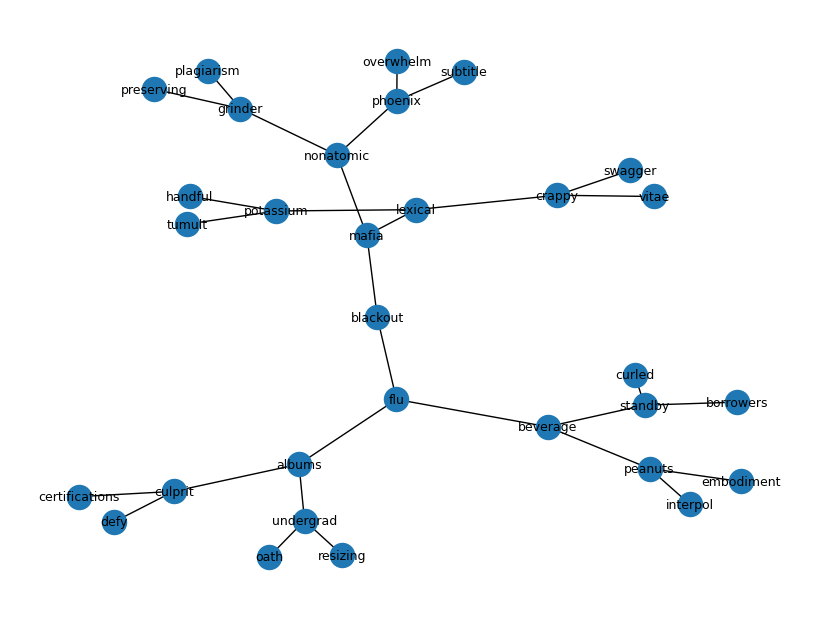

In [10]:
VOCAB_PATH = Path("../data/uncorrelated-words/selected_llama31_layer0.txt")
grid_folder = "tree_4_levels"
structure_name = "bin_tree"

STRUCT_PATH  = Path(f"../data/one_random_walk/{grid_folder}/{structure_name}_structure.txt")

EMB_DIR    = Path(f"../embeddings/{grid_folder}/")

hp_tree_das = Plotter(VOCAB_PATH, STRUCT_PATH, EMB_DIR)

G = load_graph_from_txt(STRUCT_PATH, kind="tree")
print("Grid - #nodi:", G.number_of_nodes(), "#archi:", G.number_of_edges())

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=0)  # layout automatico
nx.draw(
    G, pos,
    with_labels=True,
    node_size=300,
    font_size=9
)
plt.show()



=== CTX=3000 | file_len=3001 | t_end_ref=3000
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'standby' has only 12 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'certifications' has only 17 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'flu' has only 20 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'oath' has only 13 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'undergrad' has only 39 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'crappy' has only 3 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'nonatomic' has only 3 occurrences in [2700:3000] (requested 50)
  [ctx=3000, win_len=300, local=[2700:3000)] Warning: token 'tumult' has only 1 occu

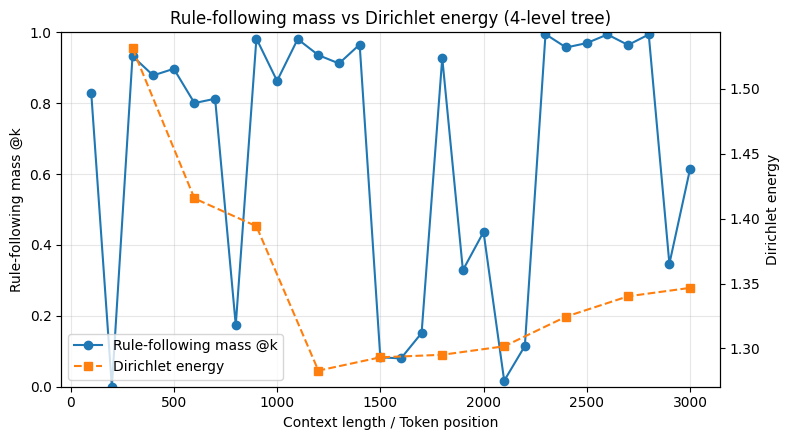

In [11]:
from sklearn.decomposition import PCA

ctx = 3000
WIN = 300
PCA_K = 10
MIN_NODES = PCA_K + 1

all_results = []
explained_ratios = []

pt_path = EMB_DIR / f"reprs_{structure_name}_one_rw_{ctx}_line000000_layer31.pt"
ids_np, emb_np = load_embeddings_pt(pt_path)

T_file = len(ids_np)
t_end_ref = min(ctx, T_file)

# Match the context-growth logic used in plot_trees.ipynb:
# suffix windows ending at the same final position, with increasing length.
CONTEXT_LENS = list(range(WIN, t_end_ref + 1, WIN))
if CONTEXT_LENS[-1] != t_end_ref:
    CONTEXT_LENS.append(t_end_ref)

graph_nodes = list(G.nodes())

print(f"\n=== CTX={ctx} | file_len={T_file} | t_end_ref={t_end_ref}")

for win_len in CONTEXT_LENS:
    t0 = max(0, t_end_ref - win_len)
    t1 = t_end_ref

    filtered_ids, filtered_emb = _window_and_filter(
        ids_np,
        emb_np,
        hp_tree_das.id_to_word,
        k=50,
        t_start=t0,
        t_end=t1,
        title=f"ctx={ctx}, win_len={win_len}, local=[{t0}:{t1})",
    )

    if len(filtered_ids) == 0:
        print(f"  [ctx={ctx}] win_len={win_len} -> vuota dopo filtro")
        all_results.append({
            "ctx": ctx,
      
            "context_len": win_len,
            "t_start_local": t0,
            "t_end_local": t1,
            "energy": np.nan,
            "energy_per_edge": np.nan,
            "energy_per_edge_dim": np.nan,
            "n_filtered": 0,
            "n_centroids": 0,
            "n_common": 0,
            "n_edges_subgraph": 0,
            "explained_ratio": None,
        })
        continue

    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    if len(centroid_ids) == 0:
        print(f"  [ctx={ctx}] win_len={win_len} -> nessun centroide")
        all_results.append({
            "ctx": ctx,
 
            "context_len": win_len,
            "t_start_local": t0,
            "t_end_local": t1,
            "energy": np.nan,
            "energy_per_edge": np.nan,
            "energy_per_edge_dim": np.nan,
            "n_filtered": len(filtered_ids),
            "n_centroids": 0,
            "n_common": 0,
            "n_edges_subgraph": 0,
            "explained_ratio": None,
        })
        continue

    labels = [hp_tree_das.id_to_word.get(int(t), str(int(t))) for t in centroid_ids]
    idx = {lab: i for i, lab in enumerate(labels)}

    # Stable node order across windows to avoid order-dependent artifacts.
    common = [node for node in graph_nodes if node in idx]

    if len(common) < MIN_NODES:
        print(f"  [ctx={ctx}] win_len={win_len} -> troppo pochi nodi comuni ({len(common)} < {MIN_NODES})")
        E = np.nan
        E_per_edge = np.nan
        E_per_edge_dim = np.nan
        explained_ratio = None
        m = 0
    else:
        X_common = np.stack([centroids[idx[lab]] for lab in common], axis=0).astype(np.float64)
        X_common = X_common - X_common.mean(axis=0, keepdims=True)

        k = min(PCA_K, len(common) - 1)
        pca = PCA(n_components=k)
        X_pca = pca.fit_transform(X_common)
        explained_ratio = pca.explained_variance_ratio_

        explained_ratios.append({
            "ctx": ctx,
     
            "context_len": win_len,
            "t_start_local": t0,
            "t_end_local": t1,
            "explained_ratio": explained_ratio,
        })

        G_sub = G.subgraph(common).copy()
        m = G_sub.number_of_edges()

        if m == 0:
            E = np.nan
            E_per_edge = np.nan
            E_per_edge_dim = np.nan
            print(f"  [ctx={ctx}] win_len={win_len} -> subgrafo senza archi")
        else:
            E = dirichlet_energy_laplacian(G_sub, common, X_pca)
            E_per_edge = E / m
            E_per_edge_dim = E / (m * X_pca.shape[1])

    print(
        f"  CTX={ctx} | win_len={win_len} | local=[{t0}:{t1}) | "
        f"E={E} | E/|E_sub|={E_per_edge}"
    )
 


    all_results.append({
        "ctx": ctx,

        "context_len": win_len,
        "t_start_local": t0,
        "t_end_local": t1,
        "energy": E,
        "energy_per_edge": E_per_edge,
        "energy_per_edge_dim": E_per_edge_dim,
        "n_filtered": len(filtered_ids),
        "n_centroids": len(centroid_ids),
        "n_common": len(common),
        "n_edges_subgraph": m,
        "explained_ratio": explained_ratio,
       
    })


logit_file = EMB_DIR / f"logit_lens_every100tok_{structure_name}_one_rw_3000_layer31.pt"

# Carica
data = torch.load(logit_file, map_location="cpu")

records = data.get("records", [])

summary, df_rule = compute_rule_following_accuracy_over_records(records, G, lowercase=True)
df = pd.DataFrame(all_results)
df_plot = df.dropna(subset=["energy"]).copy().sort_values("context_len")

fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(
    df_rule["token_position_1based"],
    df_rule["rule_following_mass_topk"],
    marker="o", label="Rule-following mass @k"
)
ax1.set_xlabel("Context length / Token position")
ax1.set_ylabel("Rule-following mass @k")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(
    df_plot["context_len"], df_plot["energy"],
    marker="s", linestyle="--", color="tab:orange", label="Dirichlet energy"
)
ax2.set_ylabel("Dirichlet energy")

plt.title("Rule-following mass vs Dirichlet energy (4-level tree)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.tight_layout()
plt.show()



In [12]:


for rec in records:
     pos1 = rec.get("token_position_1based")
     observed = rec.get("input_token_str", rec.get("last_input_token_str", ""))
     print(f"\nToken #{pos1} | osservato: {repr(observed)}")
     print("-" * 60)
     # Se hai top_decoded usa quello (più leggibile), altrimenti fallback su top_tokens
     pred_strings = rec.get("top_decoded") or rec.get("top_tokens", [])
     pred_probs = rec.get("top_probs", [])
     for s, p in zip(pred_strings, pred_probs):
         print(f"{repr(s):<20}  {p:.6f}")


Token #100 | osservato: ' albums'
------------------------------------------------------------
' flu'                0.809470
' resizing'           0.017198
' fluor'              0.014370
' culprit'            0.011367
' albums'             0.009876
' undergraduate'      0.008716
' Flu'                0.005990
' sizing'             0.003132
'flu'                 0.002897
'resize'              0.002764
' fl'                 0.002743
' fluent'             0.001799
' cult'               0.001587
' cu'                 0.001575
'Fl'                  0.001009
' Fla'                0.000978
'-fl'                 0.000940
' sizes'              0.000933
' fluid'              0.000926
'_fl'                 0.000897

Token #200 | osservato: ' swagger'
------------------------------------------------------------
'ing'                 0.408640
'er'                  0.146848
'ed'                  0.039834
'ingly'               0.039524
' potassium'          0.034879
'izer'                0.006157
'

# clustered tree

In [13]:
clustered_tree = """
root
├── c1.1
│   ├── c2.1
│   │   ├── c3.1
│   │   └── c3.2
│   └── c2.2
│       ├── c3.3
│       └── c3.4
└── c1.2
    ├── c2.3
    │   ├── c3.5
    │   └── c3.6
    └── c2.4
        ├── c3.7
        └── c3.8
"""

cluster_to_words = {
    "root": ("blackout", "vitae", "swagger"),

    "c1.1": ("mafia", "tumult", "handful"),
    "c1.2": ("flu", "overwhelm", "subtitle"),

    "c2.1": ("lexical", "preserving", "plagiarism"),
    "c2.2": ("nonatomic", "borrowers", "curled"),
    "c2.3": ("beverage", "embodiment", "interpol"),
    "c2.4": ("albums", "resizing", "oath"),

    "c3.1": ("crappy", "defy", "certifications"),
    "c3.2": ("potassium", "albeit", "mote"),
    "c3.3": ("phoenix", "tasty", "wealthiest"),
    "c3.4": ("grinder", "unconditional", "intends"),
    "c3.5": ("standby", "flaming", "fabs"),
    "c3.6": ("peanuts", "stricter", "improvised"),
    "c3.7": ("undergrad", "soar", "finns"),
    "c3.8": ("culprit", "righteous", "intimately"),
}

In [14]:
CTX_LENS = [300, 600, 1200, 1800]
EMB_DIR     = Path("../embeddings/one_random_walk/tree_clusters_3_levels/")

# 1) costruisci una volta il grafo clustered
root_c, edges_c = parse_tree_text(clustered_tree)
G_cluster = tree_to_graph(root_c, edges_c, directed=False)

# check coerenza mappa cluster -> parole
assert set(cluster_to_words.keys()) == set(G_cluster.nodes()), (
    f"Mismatch cluster labels.\n"
    f"Solo in mappa: {set(cluster_to_words.keys()) - set(G_cluster.nodes())}\n"
    f"Solo nel grafo: {set(G_cluster.nodes()) - set(cluster_to_words.keys())}"
)

energies = []

for ctx in CTX_LENS:
    pt_path = EMB_DIR / f"reprs_bin_tree_cluster_one_rw_{ctx}_line000000_layer26.pt"
    ids_np, emb_np = load_embeddings_pt(pt_path)

    filtered_ids, filtered_emb = _window_and_filter(ids_np, emb_np, hp_grid.id_to_word, k=10)
    centroid_ids, centroids = centroids_by_token(filtered_ids, filtered_emb)

    # 2) dizionario parola -> centroide parola
    word_to_centroid = build_word_centroid_map(centroid_ids, centroids, hp_grid.id_to_word)

    # 3) aggrega ai cluster (un vettore per nodo del grafo clustered)
    cluster_labels, X_cluster = aggregate_cluster_centroids(
        G_cluster=G_cluster,
        cluster_to_words=cluster_to_words,
        word_to_centroid=word_to_centroid,
        agg="mean",   # root = media dei vettori delle parole nel tuple
    )

    # # 4) standardizzazione (come nel paper, per-feature)
    # X_cluster = X_cluster.astype(np.float64).copy()
    # X_cluster = X_cluster - X_cluster.mean(axis=0, keepdims=True)                 # center per feature
    # X_cluster = X_cluster / np.clip(X_cluster.std(axis=0, keepdims=True), 1e-8, None)   

    # 5) energia sul grafo clustered
    E = dirichlet_energy_laplacian(G_cluster, cluster_labels, X_cluster)

    # (opzionale) metriche normalizzate per confronti
    m = G_cluster.number_of_edges()
    d = X_cluster.shape[1]
    E_per_edge = E / m
    E_per_edge_dim = E / (m * d)

    print(f"[ctx={ctx}] E={E:.6f}  E/|E|={E_per_edge:.6f}  E/(|E|d)={E_per_edge_dim:.8f}")
    energies.append(E)

  [] Warning: token 'blackout' has only 6 occurrences in [0:302] (requested 10)
  [] Warning: token 'peanuts' has only 1 occurrences in [0:302] (requested 10)
  [] Warning: token 'potassium' has only 5 occurrences in [0:302] (requested 10)
  [] Warning: token 'nonatomic' has only 9 occurrences in [0:302] (requested 10)
  [] Warning: token 'standby' has only 4 occurrences in [0:302] (requested 10)
  [] Warning: token 'mafia' has only 9 occurrences in [0:302] (requested 10)
  [] Warning: token 'grinder' has only 2 occurrences in [0:302] (requested 10)
  [] Warning: token 'culprit' has only 5 occurrences in [0:302] (requested 10)
  [] Warning: token 'undergrad' has only 6 occurrences in [0:302] (requested 10)
  [] Warning: token 'crappy' has only 2 occurrences in [0:302] (requested 10)
  [] Warning: token 'phoenix' has only 1 occurrences in [0:302] (requested 10)
Attenzione: parole mancanti in alcuni cluster:
  root: ['swagger']
  c1.1: ['tumult', 'handful']
  c2.1: ['preserving', 'plagia

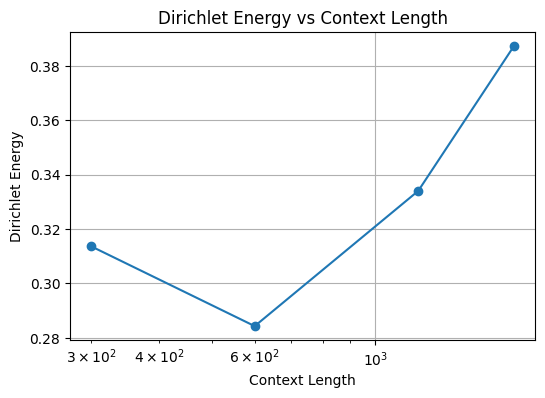

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(CTX_LENS, energies, marker="o")
plt.title("Dirichlet Energy vs Context Length")
plt.xlabel("Context Length")
plt.xscale("log")
plt.ylabel("Dirichlet Energy")
plt.grid(True)
plt.show()